# Spiking Handwritten Digits Classifier using `superneuroabm`

This tutorial demonstrates how to classify handwritten digits (sklearn 8×8 digits, 10 classes) using **SuperNeuroABM**, a GPU-accelerated agent-based spiking neural network simulator.

We build a two-layer feedforward SNN with semi-supervised STDP learning:
- **64 input LIF neurons** (one per pixel)
- **640 STDP synapses** (fully connected, bounded to [0, 1])
- **10 output LIF neurons** (one per class)
- **10 target synapses** (force correct output neuron to fire during training)

During training, input spikes use amplitude encoding (pixel value × scale),
target spikes force the correct output neuron to fire (at T+1), and
bounded STDP learns which input pixels correlate with each class.
The LTD/LTP amplitude ratio ensures common pixels (active across many classes)
receive balanced potentiation/depression and stay near zero, while class-specific
pixels accumulate net LTP only for their correct output neuron.

It also shows both halves of the "bring your own component" story: the soma
kernel and the learning rule are both ours, defined next to this notebook and
registered on the model at runtime — the installed `superneuroabm` package is
not modified. The tutorial covers training and ends at the learned weight
patterns.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import sklearn.model_selection
from pathlib import Path

from superneuroabm.model import NeuromorphicModel

# Two tutorial-owned CUDA kernels, defined next to this notebook and registered
# at runtime. Neither lives inside the superneuroabm package.
from user_customized_lif import user_customized_lif
from user_customized_stdp import user_customized_stdp

## Load and Explore the Digits Dataset

In [2]:
digits = sklearn.datasets.load_digits(n_class=10)
print(f"Data shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Classes: {np.unique(digits.target)}")
print(f"Pixel range: [{digits.data.min()}, {digits.data.max()}]")

Data shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range: [0.0, 16.0]


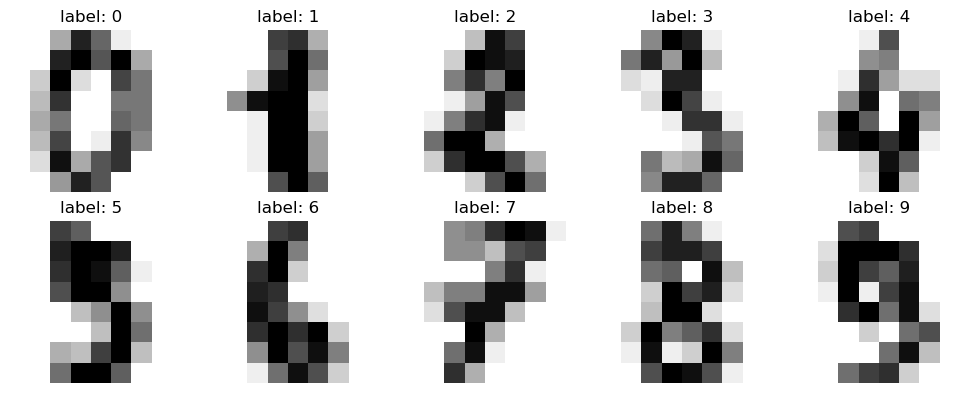

In [3]:
# Show example digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.flatten(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"label: {label}")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [4]:
# 50/50 train/test split (shuffle for interleaved class presentations — critical for STDP LTD)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    digits.data, digits.target, test_size=0.5, shuffle=True, random_state=42
)
n_classes = len(np.unique(digits.target))
input_size = X_train.shape[1]  # 64 pixels
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Classes: {n_classes}, Input size: {input_size}")

Train: 898, Test: 899, Classes: 10, Input size: 64


## Network Architecture

Two of the three kernels in this network are ours, defined next to the notebook:
`user_customized_lif.py` (the soma) and `user_customized_stdp.py` (the learning rule).
The synaptic current dynamics stay with the built-in `single_exp_synapse`.

| Component | Count | Breed / config | Purpose |
|-----------|-------|----------------|---------|
| Input somas | 64 | `user_customized_lif` / `digits_input_config` | LIF neurons, one per pixel, `vthr = -59.5` (0.5 above rest) |
| Output somas | 10 | `user_customized_lif` / `digits_output_config` | LIF neurons, one per class, `vthr = -41` (19 above rest) |
| Input synapses | 64 | `single_exp_synapse` / `digits_input_synapse_config` | External → input somas, weight 1.0, no learning |
| Target synapses | 10 | `single_exp_synapse` / `digits_target_synapse_config` | External → output somas, weight 1.0, no learning |
| Learning synapses | 640 | `single_exp_synapse` / `digits_learning_synapse_config` | Input → output, `user_customized_stdp`, weights bounded to [0, 1] |

With `C = 1e-9`, `R = 1e6` and `scaling_factor = 1e-6` at `dt = 1e-3`, the synaptic gain
`scaling_factor · dt / C` works out to exactly **1.0** — so one unit of synaptic current moves the
membrane by one unit, and the thresholds above read directly as "how much drive is needed to fire".

### Bringing your own config file

Tutorial 00 ran entirely on the packaged `component_base_config.yaml`, adjusting individual agents
with `overrides=`. That stops scaling here: this network has 788 agents drawn from five distinct
parameter sets, and two of its three kernels aren't built-ins at all. So we pass our own file with
`user_config=digits_config.yaml`.

One thing to know: `user_config=` **replaces** the packaged defaults rather than merging with them.
Every breed and `config_name` the notebook uses has to be declared in that file — which is why
`digits_config.yaml` still spells out `single_exp_synapse`, even though it is a built-in we use
unchanged. `overrides=` still works on top of it, and we use it below for the per-synapse
`stdp_type`.

### Bringing your own soma

Three steps:

1. **Write the kernel.** `user_customized_lif.py` defines a `@jit.rawkernel(device="cuda")` function
   with the framework's fixed 16-argument signature. It is the built-in LIF with one bug fixed: the
   built-in resets `tlast` branchlessly with `tlast * (1 - s) + dt * tcount * s`, and this config
   starts neurons at `tlast: -inf` so that the first spike is never gated by the refractory test.
   `-inf * 0.0` is `NaN`, so under the built-in kernel every neuron silently loses its refractory
   period the moment it first fires. Ours uses an explicit `if`.
2. **Register it before `setup()`.** `model.register_soma_type(name=..., step_func=..., step_func_path=...)`.
   Registration slots the breed into the same priority-0 phase as the built-in somas — a custom soma
   is not "after" them, it runs *with* them.
3. **Declare it in the config.** A soma breed needs its own top-level key under `soma:` in
   `digits_config.yaml`, named *exactly* what you passed to `name=`. The name also cannot be
   `lif_soma`: that breed is always registered from the package defaults, and duplicate breed names
   raise.

The file basename and the function name both have to be globally unique — `setup()` code-generates
`from <module stem> import *` for every registered breed, so a file called `lif.py` or a function
called `lif_soma_step_func` would shadow the built-in.

### Bringing your own learning rule

A synapse has two independent parts: its **breed** (the synaptic current dynamics — here the built-in
`single_exp_synapse`) and its **learning rule** (how the weight changes). Any breed can carry any
registered rule, so we keep the built-in dynamics and swap in our own plasticity.

Three steps:

1. **Write the kernel.** `user_customized_stdp.py` defines a `@jit.rawkernel(device="cuda")` function
   with the framework's fixed 16-argument signature. It implements a SuperNeuroMAT-style bounded rule:
   on a post-synaptic spike, potentiate by `pre_trace` if the pre-synaptic neuron fired recently,
   otherwise depress by `a_exp_post`; clip to `[wmin, wmax]`.
2. **Register it before `setup()`.** `model.register_learning_rule(...)` returns an auto-assigned
   integer id. The four built-in rules take 0–3, so ours gets **4**. `setup()` code-generates a
   dispatcher over all registered rules, which is why registration has to come first.
3. **Declare it in the config, then select it per synapse.** Like the soma, the rule gets its own
   block under `learning_rule:` in `digits_config.yaml`, named `user_customized_stdp`. But selection
   works differently, and this is the one asymmetry worth remembering:

   - A **soma** is chosen by `breed=`, and that name maps straight to the kernel.
   - A **learning rule** is chosen by `stdp_type`, the integer id registration handed back.
     `learning_rule=` only picks the YAML block that supplies the rule's parameters — it does not
     pick the kernel. Passing it matters for a second reason too: it is what marks the synapse as
     plastic, so `train()` and `eval()` can find it later.

   Because ids are assigned in registration order, we override `stdp_type` per synapse with the id
   we got back rather than hard-coding it in the YAML.

**Other design choices:**
- Amplitude encoding: each pixel's spike amplitude is proportional to its intensity (`pixel_value × 2.0/16`).
- **Target spikes** during training force the correct output neuron to fire (at T+1), providing the
  supervised signal that STDP needs to develop class-specific weight patterns.
- The tuned config sets `a_exp_post = 0.0`, which switches this rule's depression branch off entirely —
  weights only grow, held in check by the `wmax = 1` clamp rather than by LTD.
- Shuffled training data ensures interleaved class presentations, so consecutive samples come from
  different classes.

In [5]:
# Create model with custom config
CONFIG_DIR = Path(".").resolve()

# One name, used three times: here, in create_layer() below, and as the breed
# key under `soma:` in digits_config.yaml. All three must agree.
SOMA_BREED = "user_customized_lif"

model = NeuromorphicModel(
    user_config=CONFIG_DIR / "digits_config.yaml",
    enable_internal_states_tracking=False,
)

# Register our own soma. Must happen before setup(). The name cannot be
# "lif_soma": that breed is always registered from the package defaults, and
# re-registering an existing name raises ValueError.
model.register_soma_type(
    name=SOMA_BREED,
    step_func=user_customized_lif,
    step_func_path=CONFIG_DIR / "user_customized_lif.py",
)
print(f"Registered soma breed {SOMA_BREED!r}")

# Register our own learning rule. Must also happen before setup(), which is what
# generates the dispatch code. The four built-in rules occupy ids 0-3, so the
# first custom rule gets id 4; synapses select it by setting stdp_type to that id.
STDP_RULE_ID = model.register_learning_rule(
    step_func=user_customized_stdp,
    step_func_path=CONFIG_DIR / "user_customized_stdp.py",
)
print(f"Registered 'user_customized_stdp' as learning rule id {STDP_RULE_ID}")

Registered soma breed 'user_customized_lif'
Registered 'user_customized_stdp' as learning rule id 4


In [6]:
def create_layer(model, size, config_name):
    """Create a layer of somas using our registered custom LIF breed."""
    ids = []
    for _ in range(size):
        soma_id = model.create_soma(
            breed=SOMA_BREED,
            config_name=config_name,
        )
        ids.append(soma_id)
    return ids


def create_input_synapses(model, soma_ids, config_name):
    """Create one external-input synapse (pre=-1) per soma."""
    ids = []
    for soma_id in soma_ids:
        syn_id = model.create_synapse(
            breed="single_exp_synapse",
            pre_soma_id=-1,
            post_soma_id=soma_id,
            config_name=config_name,
        )
        ids.append(syn_id)
    return ids


def fully_connect(model, pre_ids, post_ids, config_name, stdp_rule_id):
    """Create plastic synapses between all pairs, driven by our custom rule.

    Two independent choices here. `learning_rule=` names the YAML block that
    supplies the learning hyperparameters -- our own `user_customized_stdp`
    block in digits_config.yaml. `stdp_type` is what selects the kernel, and
    since rule ids are handed out at registration time we override it with the
    id we got back rather than hard-coding it in the config.
    """
    syn_ids = []
    for pre_id in pre_ids:
        for post_id in post_ids:
            syn_id = model.create_synapse(
                breed="single_exp_synapse",
                pre_soma_id=pre_id,
                post_soma_id=post_id,
                config_name=config_name,
                learning_rule="user_customized_stdp",
                learning_rule_config="digits_learning",
                overrides={
                    "hyperparameters": {"weight": 0 * np.random.uniform(0.0, 1.0)},
                    "learning_hyperparameters": {"stdp_type": float(stdp_rule_id)},
                },
            )
            syn_ids.append(syn_id)
    return syn_ids

In [7]:
# Build the network
input_somas = create_layer(model, input_size, config_name="digits_input_config")
output_somas = create_layer(model, n_classes, config_name="digits_output_config")

input_synapses = create_input_synapses(model, input_somas, config_name="digits_input_synapse_config")
target_synapses = create_input_synapses(model, output_somas, config_name="digits_target_synapse_config")
learning_synapses = fully_connect(
    model, input_somas, output_somas,
    config_name="digits_learning_synapse_config",
    stdp_rule_id=STDP_RULE_ID,
)

print(f"Input somas: {len(input_somas)}")
print(f"Output somas: {len(output_somas)}")
print(f"Input synapses: {len(input_synapses)}")
print(f"Target synapses: {len(target_synapses)}")
print(f"Learning synapses: {len(learning_synapses)}")
print(f"Total agents: {len(input_somas) + len(output_somas) + len(input_synapses) + len(target_synapses) + len(learning_synapses)}")

# Confirm the custom soma resolved its config block. Key order in the YAML *is*
# the index order the kernel reads, and nothing validates soma configs, so a
# reordered block would fail silently -- this is where you would catch it.
print(f"Input soma hyperparameters:  {model.get_hyperparameters(input_somas[0])}")
print(f"Output soma vthr: {model.get_hyperparameters(output_somas[0])['vthr']}")

# Confirm the override landed: this must be STDP_RULE_ID, not the -1.0 placeholder.
print(f"stdp_type on a learning synapse: "
      f"{model.get_learning_hyperparameters(learning_synapses[0])['stdp_type']}")

Input somas: 64
Output somas: 10
Input synapses: 64
Target synapses: 10
Learning synapses: 640
Total agents: 788
Input soma hyperparameters:  {'C': 1e-09, 'R': 1000000.0, 'vthr': -59.5, 'tref': 0.002, 'vrest': -60.0, 'vreset': -60.0, 'tref_allows_integration': 0.0, 'I_in': 0.0, 'scaling_factor': 1e-06}
Output soma vthr: -41.0
stdp_type on a learning synapse: 4.0


## Training Encoding

Each training sample is presented over **6 ticks**. The spacing has to clear the input somas'
refractory period (`tref = 2e-3` at `dt = 1e-3`, i.e. 2 ticks) plus the fire latency, so that a soma
is ready again before the next sample arrives:
- **Tick T+0**: Amplitude-encoded input spikes (`pixel_value × SPIKE_SCALE`), matching the SuperNeuroMAT reference implementation
- **Tick T+1**: Target spike forces the correct output neuron to fire (same T+1 offset as the reference)
- **Ticks T+2..T+5**: STDP processes, voltages decay, refractory clears

We run **1 training epoch**. With bounded STDP where LTD slightly exceeds LTP, class-specific weights
reach ~0.64 after one pass. More epochs risk saturating even partially-specific pixels, reducing
discrimination. If you do raise `N_EPOCHS`, `reset(retain_parameters=True)` between epochs preserves
learned weights while clearing internal state, and spikes are re-injected for the next pass.

In [8]:
# Encoding parameters
SPIKE_SCALE = 2.0 / 16.0  # amplitude scale, matching the SuperNeuroMAT reference
TICKS_PER_SAMPLE = 6      # spacing between samples, must clear tref + fire latency
TARGET_OFFSET = 1         # target spike at T+1, same offset as the reference
N_EPOCHS = 1              # number of training epochs

def encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses):
    """Encode training data as amplitude-scaled spike lists and inject into the model."""
    input_spike_lists = {syn_id: [] for syn_id in input_synapses}
    target_spike_lists = {syn_id: [] for syn_id in target_synapses}

    for sample_idx, (image, label) in enumerate(zip(X_train, y_train)):
        t_base = sample_idx * TICKS_PER_SAMPLE
        for pixel_idx, pixel_val in enumerate(image):
            amplitude = pixel_val * SPIKE_SCALE
            if amplitude > 0:
                input_spike_lists[input_synapses[pixel_idx]].append([t_base, amplitude])
        # Target spike forces correct output neuron to fire at T+1
        target_spike_lists[target_synapses[label]].append([t_base + TARGET_OFFSET, 20.0])

    for syn_id, spikes in input_spike_lists.items():
        if spikes:
            model.add_spike_list(syn_id, spikes)
    for syn_id, spikes in target_spike_lists.items():
        if spikes:
            model.add_spike_list(syn_id, spikes)

total_training_ticks = len(X_train) * TICKS_PER_SAMPLE
print(f"Training samples: {len(X_train)}")
print(f"Total training ticks per epoch: {total_training_ticks}")
print(f"Training epochs: {N_EPOCHS}")

Training samples: 898
Total training ticks per epoch: 5388
Training epochs: 1


In [9]:
# Setup and run training (no normalization needed — bounded STDP constrains weights)
model.setup()
encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses)

for epoch in range(N_EPOCHS):
    if epoch > 0:
        model.reset(retain_parameters=True)
        encode_training_spikes(model, X_train, y_train, input_synapses, target_synapses)
    model.simulate(ticks=total_training_ticks)
    print(f"Epoch {epoch + 1}/{N_EPOCHS} complete")

Epoch 1/1 complete


## Extract and Visualize Learned Weights

In [10]:
# Extract the 64x10 weight matrix from learning synapses
# learning_synapses is ordered: [input_0->output_0, input_0->output_1, ..., input_63->output_9]
weight_matrix = np.zeros((input_size, n_classes))
for i, hp in enumerate(model.get_hyperparameters(learning_synapses)):
    pre_idx = i // n_classes
    post_idx = i % n_classes
    weight_matrix[pre_idx, post_idx] = hp["weight"]

print(f"Weight matrix shape: {weight_matrix.shape}")
print(f"Weight range: [{weight_matrix.min():.4f}, {weight_matrix.max():.4f}]")

Weight matrix shape: (64, 10)
Weight range: [0.0000, 0.6400]


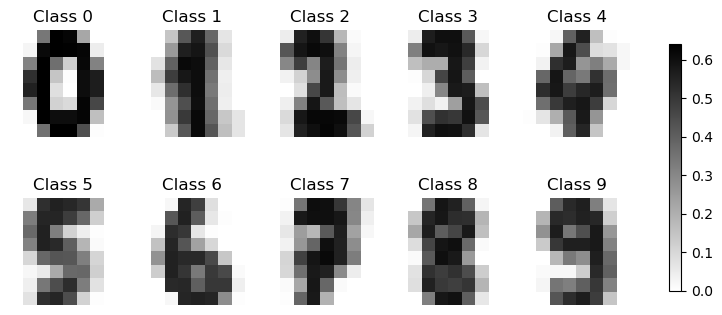

In [11]:
# Visualize learned weight patterns per class as 8x8 images
images = weight_matrix.T.reshape(n_classes, 8, 8)

vmin = weight_matrix.min()   # wmin
vmax = weight_matrix.max()   # wmax

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, cls in zip(axes.flat, images, range(n_classes)):
    im = ax.imshow(
        image,
        cmap="gray_r",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Class {cls}")
    ax.axis("off")

# colorbar(ax=...) manages the layout itself, so no tight_layout() here.
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()